In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsforecast import StatsForecast
from statsforecast.models import Naive, HistoricAverage, WindowAverage, SeasonalNaive
from sklearn.feature_selection import mutual_info_classif
from sklearn.ensemble import RandomForestClassifier
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [2]:
data = pd.read_csv('synthetic_data.csv')
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 267 entries, 0 to 266
Data columns (total 22 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   Cycle_Length            267 non-null    int64
 1   Age_Range               267 non-null    int64
 2   Irregular_Periods       267 non-null    int64
 3   Weight_Gain             267 non-null    int64
 4   Hair_Loss               267 non-null    int64
 5   Skin_Darkening          267 non-null    int64
 6   Pimples                 267 non-null    int64
 7   Fast_Food_Intake        267 non-null    int64
 8   Hair_Growth_Chin        267 non-null    int64
 9   Hair_Growth_Cheeks      267 non-null    int64
 10  Hair_Growth_Upper_Lips  267 non-null    int64
 11  Hair_Growth_Arms        267 non-null    int64
 12  Hair_Growth_Legs        267 non-null    int64
 13  Hair_Growth_Back        267 non-null    int64
 14  Acne                    267 non-null    int64
 15  Dark_Patches           

In [3]:
pcos = data[data['PCOS_Diagnosis']==1]
pcos

,Cycle_Length,Age_Range,Irregular_Periods,Weight_Gain,Hair_Loss,Skin_Darkening,Pimples,Fast_Food_Intake,Hair_Growth_Chin,Hair_Growth_Cheeks,...,Hair_Growth_Legs,Hair_Growth_Back,Acne,Dark_Patches,Hair_Thinning,Skin_Tags,Mood_Swings,Fatigue_Level,Exercise_Days_Per_Week,PCOS_Diagnosis
1,4,6,1,0,1,0,1,0,0,0,...,1,2,1,0,0,0,1,1,1,1
4,4,1,1,1,0,0,0,1,2,2,...,1,2,1,0,0,1,2,0,7,1
7,2,3,1,1,0,0,0,1,0,2,...,1,2,1,1,1,1,1,7,0,1
9,4,0,1,1,1,0,0,1,1,1,...,1,2,0,1,0,1,6,5,3,1
11,2,3,1,0,1,1,0,0,0,1,...,0,2,1,1,1,0,4,0,3,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
252,3,4,1,1,1,1,1,1,0,1,...,1,2,0,0,1,0,7,5,0,1
257,3,0,1,0,1,1,0,0,1,1,...,1,0,1,1,0,1,4,2,0,1
258,3,5,1,1,1,1,0,0,2,1,...,2,2,0,1,0,1,7,6,0,1
262,0,4,0,1,1,1,1,2,1,0,...,1,0,1,0,0,1,6,1,5,1


In [6]:
pcos.corr()

,Cycle_Length,Age_Range,Irregular_Periods,Weight_Gain,Hair_Loss,Skin_Darkening,Pimples,Fast_Food_Intake,Hair_Growth_Chin,Hair_Growth_Cheeks,Hair_Growth_Upper_Lips,Hair_Growth_Arms,Hair_Growth_Legs,Hair_Growth_Back,Acne,Dark_Patches,Hair_Thinning,Skin_Tags,Mood_Swings,Fatigue_Level,Exercise_Days_Per_Week,PCOS_Diagnosis
Cycle_Length,1.000000,0.209119,0.048086,-0.218649,-0.208606,-0.067240,-0.006398,-0.031357,0.032330,-0.072557,-0.251433,-0.154337,0.160618,0.268228,-0.044408,0.046725,0.130016,0.037023,-0.002762,-0.131209,0.032074,NaN
Age_Range,0.209119,1.000000,0.067479,-0.098335,-0.031584,-0.008597,0.097990,-0.243717,-0.026174,-0.152097,-0.161999,-0.227910,-0.063500,0.105528,0.008368,0.038129,0.022973,-0.046444,0.085687,-0.047585,0.014912,NaN
Irregular_Periods,0.048086,0.067479,1.000000,-0.317857,-0.027187,-0.018195,0.007932,-0.140247,-0.003211,0.121914,0.019682,-0.153736,-0.165024,0.017890,-0.283950,0.182879,0.152469,-0.038686,0.043387,0.016503,0.019594,NaN
Weight_Gain,-0.218649,-0.098335,-0.317857,1.000000,-0.107767,0.017901,0.007932,0.252302,0.018733,0.100118,0.110181,-0.021809,0.079529,0.017890,-0.091627,0.002638,0.044066,-0.002638,0.124615,0.129275,0.057969,NaN
Hair_Loss,-0.208606,-0.031584,-0.027187,-0.107767,1.000000,0.144482,0.064019,-0.031840,-0.003780,-0.181456,0.181678,-0.087290,-0.053430,-0.003610,-0.273852,-0.087816,-0.191168,-0.203131,0.005996,0.027010,-0.143850,NaN
Skin_Darkening,-0.067240,-0.008597,-0.018195,0.017901,0.144482,1.000000,0.061338,-0.099681,-0.071116,-0.196203,0.057525,0.172889,-0.087568,-0.030031,0.004805,-0.023046,0.093999,-0.074702,0.120156,-0.157786,0.087027,NaN
Pimples,-0.006398,0.097990,0.007932,0.007932,0.064019,0.061338,1.000000,0.021177,0.170957,0.015873,-0.120832,0.024748,-0.053970,0.106375,0.053479,0.006364,0.019139,-0.038982,0.009142,0.121452,-0.065382,NaN
Fast_Food_Intake,-0.031357,-0.243717,-0.140247,0.252302,-0.031840,-0.099681,0.021177,1.000000,0.095286,-0.008225,0.138118,0.073411,0.000987,-0.160782,0.055672,0.039852,-0.116953,-0.020166,0.069999,0.044060,0.137225,NaN
Hair_Growth_Chin,0.032330,-0.026174,-0.003211,0.018733,-0.003780,-0.071116,0.170957,0.095286,1.000000,0.113342,-0.096125,-0.094597,-0.132894,-0.023875,-0.021652,-0.048797,-0.126886,0.187459,-0.017092,0.041716,0.006789,NaN
Hair_Growth_Cheeks,-0.072557,-0.152097,0.121914,0.100118,-0.181456,-0.196203,0.015873,-0.008225,0.113342,1.000000,-0.107418,0.071027,-0.009372,0.005300,-0.045741,0.005278,0.075037,0.034070,-0.143701,0.065852,-0.006403,NaN


<Axes: xlabel='Cycle_Length'>

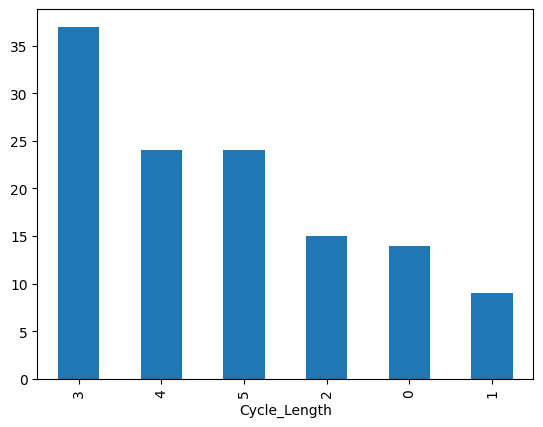

In [10]:
pcos['Cycle_Length'].value_counts().plot(kind='bar')

<Axes: xlabel='Age_Range'>

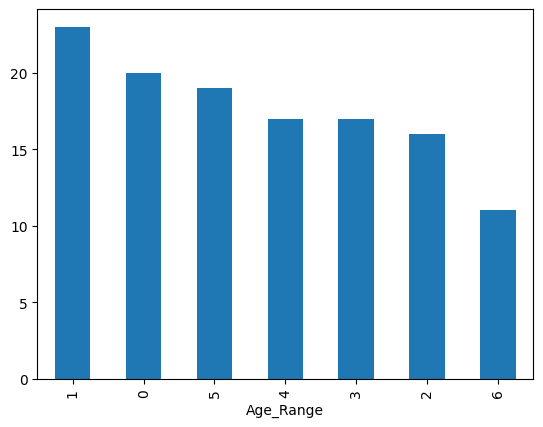

In [12]:
pcos['Age_Range'].value_counts().plot(kind='bar')